# 1. Compiling the Dataset and Engineering Features

### Data Cleaning / Combining into DataFrame used in model training

First, we read in the 'labels' - hourly energy demand. Our analysis will focus on the load zone 'COAS', which includes Houston, TX. See the image below for reference (Coast).

<img src="https://www.ercot.com/files/assets/2023/04/26/Weather.jpg?" width="50%">


In [5]:
import pandas as pd
import numpy as np

df_demand = pd.read_csv("ercot_demand.csv")
df_demand["period"] = pd.to_datetime(df_demand["period"])
df_demand.head()

,period,COAS,EAST,FWES,NCEN,NRTH,SCEN,SOUT,WEST
0,2023-06-01 00:00:00,17008.0,2373.0,5998.0,20016.0,1692.0,11267.0,5320.0,1712.0
1,2023-06-01 01:00:00,16423.0,2247.0,5964.0,19076.0,1681.0,10901.0,5135.0,1502.0
2,2023-06-01 02:00:00,15935.0,2122.0,5921.0,18104.0,1615.0,10416.0,4956.0,1408.0
3,2023-06-01 03:00:00,15387.0,2025.0,5980.0,17320.0,1550.0,10007.0,4804.0,1352.0
4,2023-06-01 04:00:00,14520.0,1885.0,5876.0,16056.0,1442.0,9321.0,4457.0,1337.0


To verify our import worked and the data looks good, we can plot a random week in the year.

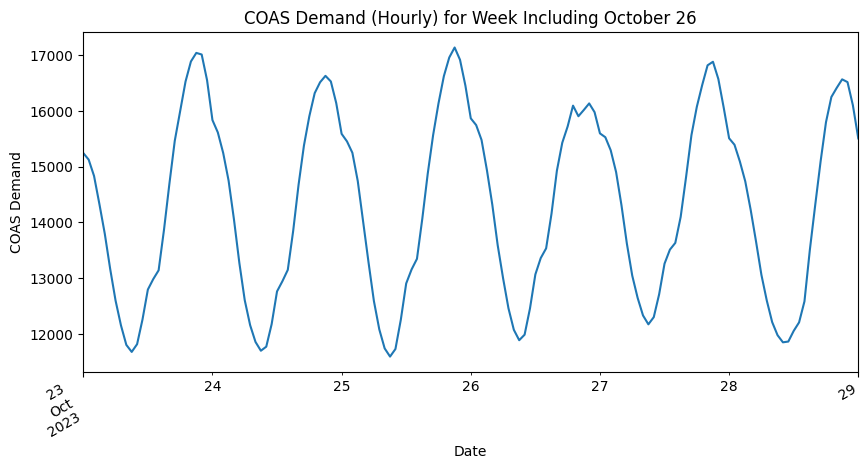

In [17]:
df_demand_oct = df_demand[df_demand["period"].dt.month == 10]
# Find the monday-sunday week in October that includes October 26
oct_26 = df_demand_oct[df_demand_oct["period"].dt.day == 26].iloc[0]["period"]
start_of_week = oct_26 - pd.Timedelta(days=oct_26.dayofweek)  # Monday of the week
end_of_week = start_of_week + pd.Timedelta(days=6)  # Sunday of the week
df_demand_week = df_demand_oct[
    (df_demand_oct["period"] >= start_of_week) &
    (df_demand_oct["period"] <= end_of_week)
]

import matplotlib.dates as mdates

ax = df_demand_week.set_index("period")["COAS"].plot(figsize=(10, 5))
ax.set_xlabel("Date")
ax.set_ylabel("COAS Demand")
ax.set_title("COAS Demand (Hourly) for Week Including October 26")
ax.figure.autofmt_xdate()






Next, we import weather data - see [column descriptions](https://mesonet.agron.iastate.edu/request/download.phtml?network=TX_ASOS). This file contains data for all the weather stations shown in the image below.

![Img error]('weather_stations.png')

In [19]:
df_weather = pd.read_csv("asos.csv")

df_weather.head()


,station,valid,lon,lat,tmpf,dwpf,relh,drct,sknt,p01i,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,ARM,2023-06-01 00:15,-96.1544,29.2543,70.7,70.7,100.00,90.0,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.7,KARM 010515Z AUTO 09003KT 10SM CLR 22/22 A2989...,NaN
1,AXH,2023-06-01 00:15,-95.4769,29.5061,71.6,70.2,95.35,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.6,KAXH 010515Z AUTO 00000KT 10SM CLR 22/21 A2991...,NaN
2,BYY,2023-06-01 00:15,-95.8634,28.9733,70.3,69.0,95.98,80.0,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.3,KBYY 010515Z AUTO 08004KT 10SM CLR 21/20 A2988...,NaN
3,MCJ,2023-06-01 00:15,-95.3950,29.7140,75.2,68.0,78.34,150.0,7.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.2,KMCJ 010515Z AUTO 15007KT 10SM FEW041 BKN049 B...,NaN
4,T41,2023-06-01 00:15,-95.0641,29.6692,76.0,69.0,78.93,160.0,5.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.9,KT41 010515Z AUTO 16005KT 10SM CLR 24/21 A2989...,NaN


The type of day (school day, school holiday but workday, weekend, etc) may influence energy consumption patterns as well. Hence we import [Houston's school district calendar](https://www.fox26houston.com/news/houston-isd-calendar-for-2023-2024-academic-school-year-updated-released)

In [20]:
df_calendar = pd.read_csv('hisd_2023_2024_day_categories_with_business(1).csv')
df_calendar.head()

,day,school_category,business_category
0,2023-06-01,summer_break_weekday,normal_business_day
1,2023-06-02,summer_break_weekday,normal_business_day
2,2023-06-03,weekend_school_break,weekend
3,2023-06-04,weekend_school_break,weekend
4,2023-06-05,summer_break_weekday,normal_business_day


The most closely followed sports phenomenon in Houston is a Houston Texans game - this may also affect consumption in the region. Here, we scrape the official Houston Texans website for Texans games within the timeframe of our analysis.

In [9]:
import requests, json
from bs4 import BeautifulSoup

resp = requests.get("https://www.houstontexans.com/schedule/2023/")
soup = BeautifulSoup(resp.text, "html.parser")
games = []
for script in soup.find_all("script", type="application/ld+json"):
    data = json.loads(script.string)
    if data.get("@type") == "SportsEvent":
        is_home = data["homeTeam"]["name"] == "Houston Texans"
        opponent = data["awayTeam"]["name"] if is_home else data["homeTeam"]["name"]
        games.append({
            "datetime": data["startDate"],
            "end_datetime": data["endDate"],
            "location": "home" if is_home else "away",
            "opponent": opponent,
        })

df_texans = pd.DataFrame(games)
df_texans["datetime"] = pd.to_datetime(df_texans["datetime"])
df_texans["end_datetime"] = pd.to_datetime(df_texans["end_datetime"])
df_texans = df_texans.sort_values("datetime").reset_index(drop=True)
df_texans

,datetime,end_datetime,location,opponent
0,2023-08-10 23:00:00,2023-08-11 02:30:00,away,New England Patriots
1,2023-08-19 20:00:00,2023-08-19 23:30:00,home,Miami Dolphins
2,2023-08-28 00:00:00,2023-08-28 03:30:00,away,New Orleans Saints
3,2023-09-10 17:00:00,2023-09-10 20:30:00,away,Baltimore Ravens
4,2023-09-17 17:00:00,2023-09-17 20:30:00,home,Indianapolis Colts
5,2023-09-24 17:00:00,2023-09-24 20:30:00,away,Jacksonville Jaguars
6,2023-10-01 17:00:00,2023-10-01 20:30:00,home,Pittsburgh Steelers
7,2023-10-08 17:00:00,2023-10-08 20:30:00,away,Atlanta Falcons
8,2023-10-15 17:00:00,2023-10-15 20:30:00,home,New Orleans Saints
9,2023-10-29 17:00:00,2023-10-29 20:30:00,away,Carolina Panthers


Now that we have gathered all relevant data, we combine the datasets into one DataFrame.

In [23]:
# Standardize date columns for merging
df_calendar['day'] = pd.to_datetime(df_calendar['day'])
df_weather['valid'] = pd.to_datetime(df_weather['valid'])

# Initialize the combined dataframe with the demand labels (COAS)
df_final = df_demand[['period', 'COAS']].copy()

# Merge daily calendar data
df_final['date_key'] = df_final['period'].dt.normalize()
df_final = df_final.merge(df_calendar, left_on='date_key', right_on='day', how='left')

# Merge weather data (using 'h' instead of 'H' to avoid FutureWarning)
weather_hourly = df_weather.groupby(df_weather['valid'].dt.floor('h')).mean(numeric_only=True).reset_index()
df_final = df_final.merge(weather_hourly, left_on='period', right_on='valid', how='left')

# Add a flag for Houston Texans games
def is_game_active(ts):
    return any((ts >= df_texans['datetime']) & (ts <= df_texans['end_datetime']))
df_final['is_texans_game'] = df_final['period'].apply(is_game_active)

# Clean up temporary columns used for merging
df_final = df_final.drop(columns=['date_key', 'day', 'valid'])

df_final.head()

,period,COAS,school_category,business_category,lon,lat,tmpf,dwpf,relh,drct,...,skyl3,skyl4,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,feel,snowdepth,is_texans_game
0,2023-06-01 00:00:00,17008.0,summer_break_weekday,normal_business_day,-95.570936,29.532508,72.472000,68.93200,89.052000,88.400000,...,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,72.460000,NaN,False
1,2023-06-01 01:00:00,16423.0,summer_break_weekday,normal_business_day,-95.570936,29.532508,72.044000,68.91600,90.120800,77.600000,...,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,72.048000,NaN,False
2,2023-06-01 02:00:00,15935.0,summer_break_weekday,normal_business_day,-95.570936,29.532508,70.952000,68.27600,91.469200,44.400000,...,7000.0,NaN,NaN,NaN,NaN,NaN,NaN,70.944000,NaN,False
3,2023-06-01 03:00:00,15387.0,summer_break_weekday,normal_business_day,-95.570936,29.532508,70.244000,67.58000,91.496400,48.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.240000,NaN,False
4,2023-06-01 04:00:00,14520.0,summer_break_weekday,normal_business_day,-95.555924,29.474038,69.051724,66.92069,93.142069,23.103448,...,7000.0,NaN,NaN,NaN,NaN,NaN,NaN,69.051724,NaN,False


Now that the data is all in one place, we can clean and apply some preprocessing for our machine learning models. One noteworthy preprocessing step is encoding the hour as a cyclical variable to capture the adjacency between 11pm and 12am (23 vs 0).

In [24]:
# Drop nonsensical, redundant, and observation-only features
# - lat/lon: nonsensical for model
# - feel/mslp: highly correlated/redundant
# - alti, skyl1-4, ice_accretion_*, peak_wind_*, metar: observation-only, not available in forecasts
cols_to_drop = [
    'lon', 'lat', 'feel', 'mslp',
    'alti',
    'skyl1', 'skyl2', 'skyl3', 'skyl4',
    'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr',
    'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time',
    'metar'
]
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# Datetime conversion (extract features and set index)
# Encode hour cyclically so that hour 23 and 0 are adjacent
# Cyclical encoding for hour, day_of_week, and month
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['period'].dt.hour / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['period'].dt.hour / 24)

# day of week and month
df_final['day_of_week'] = df_final['period'].dt.dayofweek
df_final['month'] = df_final['period'].dt.month

df_final = df_final.set_index('period')

# Categorical encoding
df_final = pd.get_dummies(df_final, columns=['school_category', 'business_category'], drop_first=True)

# Missing values
df_final['snowdepth'] = df_final['snowdepth'].fillna(0)
df_final = df_final.ffill()

# Boolean conversion
df_final['is_texans_game'] = df_final['is_texans_game'].astype(int)

# Time-series lag features
df_final['COAS_lag_24h'] = df_final['COAS'].shift(24)
df_final = df_final.dropna(subset=['COAS_lag_24h'])

df = df_final.copy()
df.head()

,COAS,tmpf,dwpf,relh,drct,sknt,p01i,vsby,gust,snowdepth,...,school_category_spring_break_weekday,school_category_summer_break_weekday,school_category_thanksgiving_break_weekday,school_category_weekend_school_break,school_category_weekend_school_term,school_category_winter_break_weekday,business_category_normal_business_day,business_category_partial_business_closure,business_category_weekend,COAS_lag_24h
period,,,,,,,,,,,,,,,,,,,,,
2023-06-02 00:00:00,17702.0,72.240000,68.248000,87.696000,55.217391,1.160000,0.0,9.630000,10.0,0.0,...,False,True,False,False,False,False,True,False,False,17008.0
2023-06-02 01:00:00,16958.0,71.280769,67.873077,89.434231,56.153846,1.000000,0.0,8.807692,10.0,0.0,...,False,True,False,False,False,False,True,False,False,16423.0
2023-06-02 02:00:00,16357.0,69.957692,67.684615,92.812692,0.000000,0.307692,0.0,8.144231,10.0,0.0,...,False,True,False,False,False,False,True,False,False,15935.0
2023-06-02 03:00:00,15755.0,69.546154,67.207692,92.618077,12.307692,0.230769,0.0,6.750000,10.0,0.0,...,False,True,False,False,False,False,True,False,False,15387.0
2023-06-02 04:00:00,14859.0,69.151852,67.081481,93.400000,18.518519,0.333333,0.0,6.259259,10.0,0.0,...,False,True,False,False,False,False,True,False,False,14520.0


# 2. Implementing, Tuning, and Evaluating ML Models

For all the following models, we use an 80/20 chronologically ordered train-test split: training is carried out on data from June 2023 to late March 2024, and testing on data from late March to late May 2024.

## Baseline

We first implement a simple linear regression as baseline.

Linear Regression - MAE:  894.04
Linear Regression - RMSE: 1257.77
Linear Regression - MAPE: 6.87%


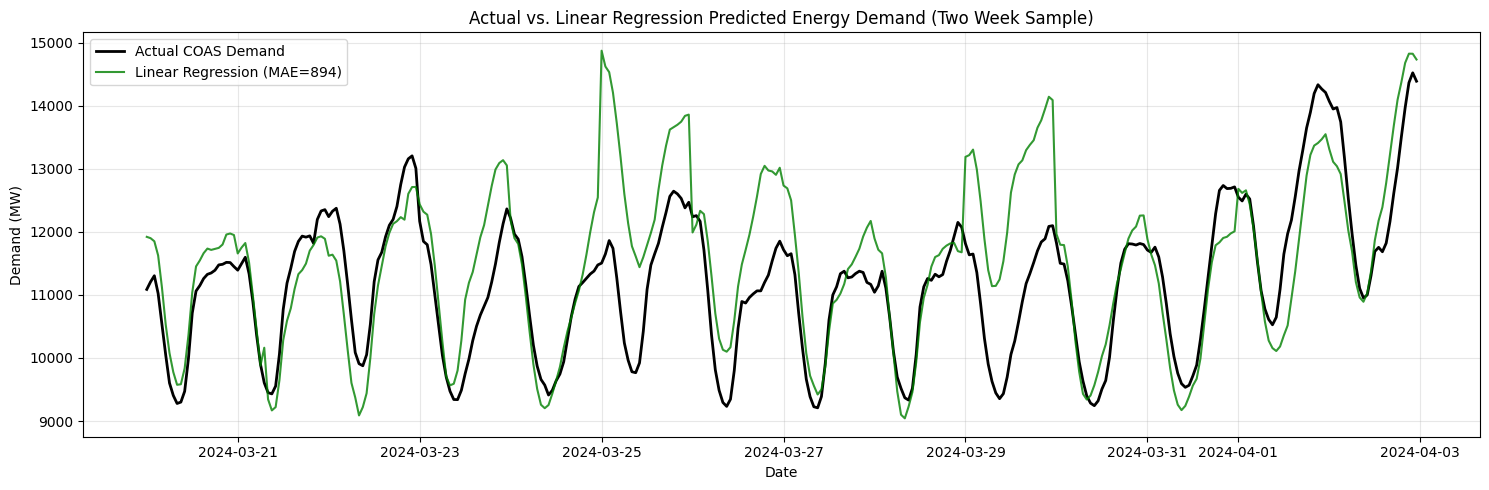

In [25]:
# Linear Regression Baseline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

y = df['COAS']
X = df.drop(columns=['COAS'])

split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print(f"Linear Regression - MAE:  {mae_lr:.2f}")
print(f"Linear Regression - RMSE: {rmse_lr:.2f}")
print(f"Linear Regression - MAPE: {mape_lr:.2f}%")

# Plot first 2 weeks of test set
hours_to_plot = 24 * 14
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:hours_to_plot], y_test.values[:hours_to_plot],
         label="Actual COAS Demand", color="black", linewidth=2)
plt.plot(y_test.index[:hours_to_plot], y_pred_lr[:hours_to_plot],
         label=f"Linear Regression (MAE={mae_lr:.0f})", color="green", alpha=0.8)
plt.title("Actual vs. Linear Regression Predicted Energy Demand (Two Week Sample)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As we can see from the graph, linear regression manages to capture the cyclical nature of electricity demand but is quite inaccurate. Notably, our MAE is 894 (we'll compare this to other models below).

## Model #1: XGBoost

XGBoost performs very well with non-linear relationships and tabular data, and is known to be efficient for time-series datasets. Hyperparameters were tuned using grid search (for clarity, this is not included in this notebook).

In [12]:
!pip install xgboost

Training XGBoost Regressor...
Test Mean Absolute Error (MAE): 663.01
Test Root Mean Squared Error (RMSE): 962.10


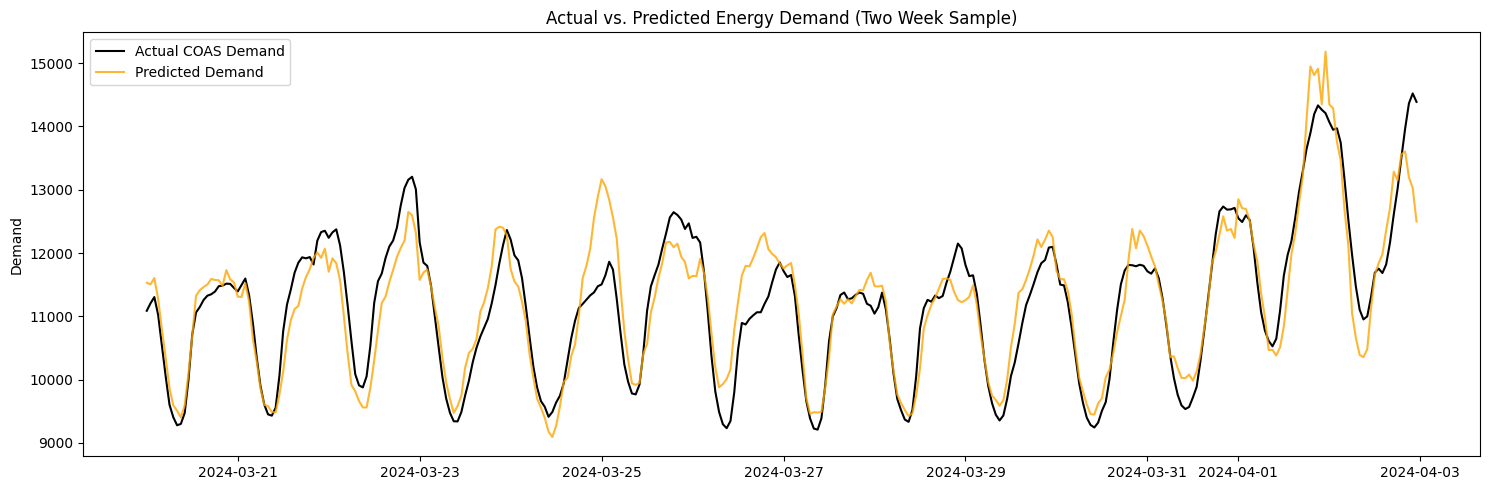

In [27]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

y = df['COAS']
X = df.drop(columns=['COAS'])

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 2. Initialize and Train the XGBoost Model
print("Training XGBoost Regressor...")
best_xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror',
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42
)
best_xgb_model.fit(X_train, y_train)

# 3. Make Predictions and Evaluate
y_pred = best_xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test Mean Absolute Error (MAE): {mae:.2f}")
print(f"Test Root Mean Squared Error (RMSE): {rmse:.2f}")

hours_to_plot = 24 * 14
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:hours_to_plot], y_test.values[:hours_to_plot], label='Actual COAS Demand', color='black')
plt.plot(y_test.index[:hours_to_plot], y_pred[:hours_to_plot], label='Predicted Demand', color='orange', alpha=0.8)
plt.title('Actual vs. Predicted Energy Demand (Two Week Sample)')
plt.ylabel('Demand')
plt.legend()
plt.tight_layout()
plt.show()

XGBoost is much more accurate compared to Linear Regression, as shown visually in the figure as well as by the lower MAE.

## Model #2: Neural Network

Neural networks take a different approach to prediction than XGBoost. The idea here is to provide a 'diverse' perspective to our prediction so that we can increase overall accuracy with an ensembling approach later on.

Neural Network - MAE:  715.94
Neural Network - RMSE: 966.19
Neural Network - MAPE: 5.32%


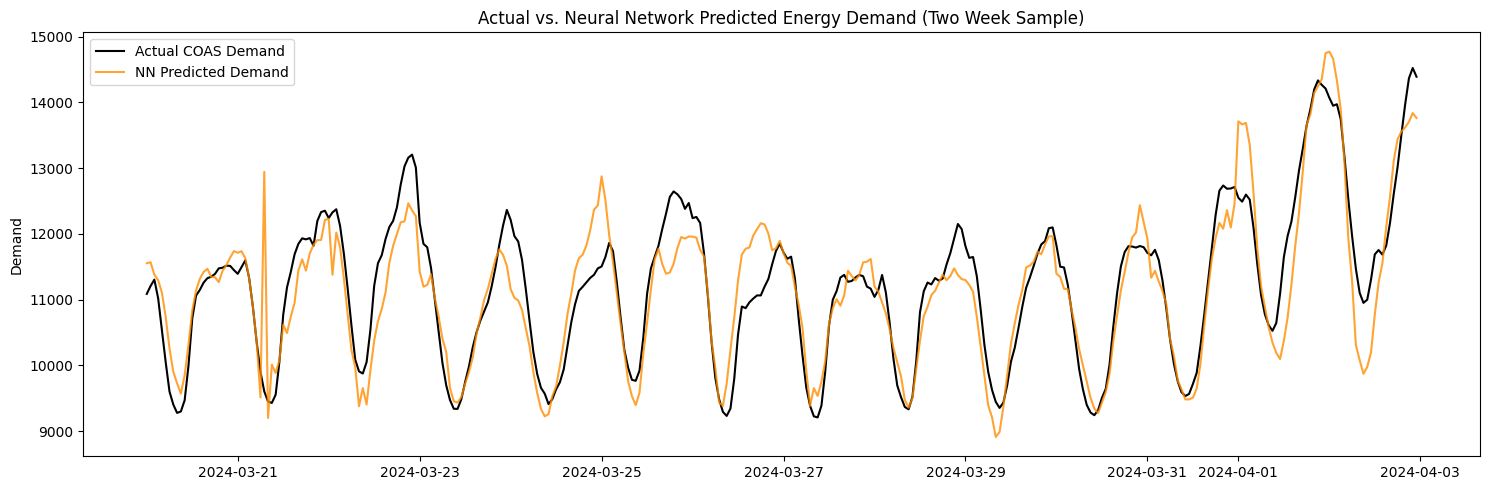

In [29]:
# Neural Network

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

y = df['COAS']
X = df.drop(columns=['COAS'])

split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 50, 50, 50, 50),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_test_scaled)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mape_nn = np.mean(np.abs((y_test - y_pred_nn) / y_test)) * 100

print(f"Neural Network - MAE:  {mae_nn:.2f}")
print(f"Neural Network - RMSE: {rmse_nn:.2f}")
print(f"Neural Network - MAPE: {mape_nn:.2f}%")

hours_to_plot = 24 * 14
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:hours_to_plot], y_test.values[:hours_to_plot],
         label="Actual COAS Demand", color="black")
plt.plot(y_test.index[:hours_to_plot], y_pred_nn[:hours_to_plot],
         label="NN Predicted Demand", color="darkorange", alpha=0.8)
plt.title("Actual vs. Neural Network Predicted Energy Demand (Two Week Sample)")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()


Although the neural network performs worse than XGBoost, it beats the LinReg baseline.

## Model #3: LSTM (Long Short-Term Memory)

LSTM models are considered industry standard for sequential data. Hence, we implement one below in an effort to improve upon our XGBoost performance.

Using device: cpu
Training LSTM...
  Epoch 1/200 - Loss: 0.054218
  Epoch 5/200 - Loss: 0.013256
  Epoch 10/200 - Loss: 0.009684
  Epoch 15/200 - Loss: 0.008121
  Epoch 20/200 - Loss: 0.007005
  Epoch 25/200 - Loss: 0.006332
  Epoch 30/200 - Loss: 0.005620
  Epoch 35/200 - Loss: 0.004973
  Epoch 40/200 - Loss: 0.004628
  Epoch 45/200 - Loss: 0.004426
  Epoch 50/200 - Loss: 0.004060
  Epoch 55/200 - Loss: 0.003812
  Epoch 60/200 - Loss: 0.003709
  Epoch 65/200 - Loss: 0.003691
  Epoch 70/200 - Loss: 0.003596
  Epoch 75/200 - Loss: 0.003523
  Epoch 80/200 - Loss: 0.003368
  Epoch 85/200 - Loss: 0.003465
  Epoch 90/200 - Loss: 0.003372
  Epoch 95/200 - Loss: 0.003231
  Epoch 100/200 - Loss: 0.003228
  Epoch 105/200 - Loss: 0.003165
  Epoch 110/200 - Loss: 0.003135
  Epoch 115/200 - Loss: 0.003124
  Epoch 120/200 - Loss: 0.003016
  Epoch 125/200 - Loss: 0.002914
  Epoch 130/200 - Loss: 0.002907
  Epoch 135/200 - Loss: 0.002855
  Epoch 140/200 - Loss: 0.002923
  Epoch 145/200 - Loss: 0.0028

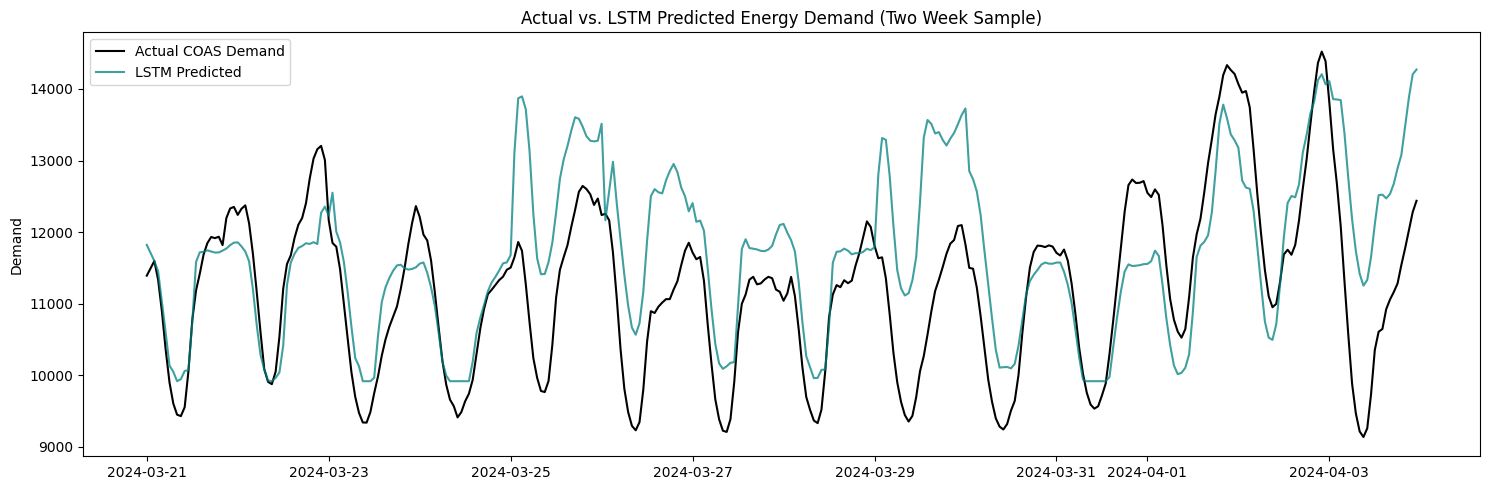

In [16]:
# LSTM Model (PyTorch)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


# 1. Scale features
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

# 2. Create sequences (look back 24 hours)
SEQ_LENGTH = 24

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(seq_length, len(X)):
        Xs.append(X[i - seq_length:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

# 3. DataLoader

X_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        # LSTM Layer (64 neurons)
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)

        # Linear Layer 1 (32 neurons)
        self.fc1 = nn.Linear(64, 32)
        # Linear Layer 2 (16 neurons)
        self.fc2 = nn.Linear(32, 16)
        # Output Layer (1 neuron)
        self.fc3 = nn.Linear(16, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Use only the last hidden state from the sequence
        out = self.dropout(lstm_out[:, -1, :])
        out = self.relu(self.fc1(out))
        out = self.relu(self.fc2(out))
        return self.fc3(out)


device = torch.device("cpu")
print(f"Using device: {device}")


model = LSTMModel(input_size=X_train_scaled.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. Train
EPOCHS = 200
print("Training LSTM...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_hat = model(X_batch).squeeze()
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss / len(train_dataset):.6f}")

# 6. Predict and evaluate
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.FloatTensor(X_test_seq).to(device)).squeeze().cpu().numpy()

y_pred_lstm = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_lstm = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mape_lstm = np.mean(np.abs((y_test_lstm - y_pred_lstm) / y_test_lstm)) * 100

print(f"\nLSTM - MAE:  {mae_lstm:.2f}")
print(f"LSTM - RMSE: {rmse_lstm:.2f}")
print(f"LSTM - MAPE: {mape_lstm:.2f}%")

# 7. Plot (first 14 days)
hours_to_plot = 24 * 14
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[SEQ_LENGTH:SEQ_LENGTH + hours_to_plot], y_test_lstm[:hours_to_plot],
         label="Actual COAS Demand", color="black")
plt.plot(y_test.index[SEQ_LENGTH:SEQ_LENGTH + hours_to_plot], y_pred_lstm[:hours_to_plot],
         label="LSTM Predicted", color="teal", alpha=0.75)
plt.title("Actual vs. LSTM Predicted Energy Demand (Two Week Sample)")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

Surprisingly, our LSTM model seems to perform worse than even our baseline LinReg. Below, we see that it still brings value in the ensembling.

## Ensembled Model

We combine the results of our four models in hopes of making one that is more accurate than all of them.

Ensemble (4-model stack) - MAE:  652.93
Ensemble (4-model stack) - RMSE: 939.09
Ensemble (4-model stack) - MAPE: 4.95%

Meta-learner weights:
      LinReg: -0.2135
     XGBoost: 1.0495
   NeuralNet: 0.0822
        LSTM: 0.0881


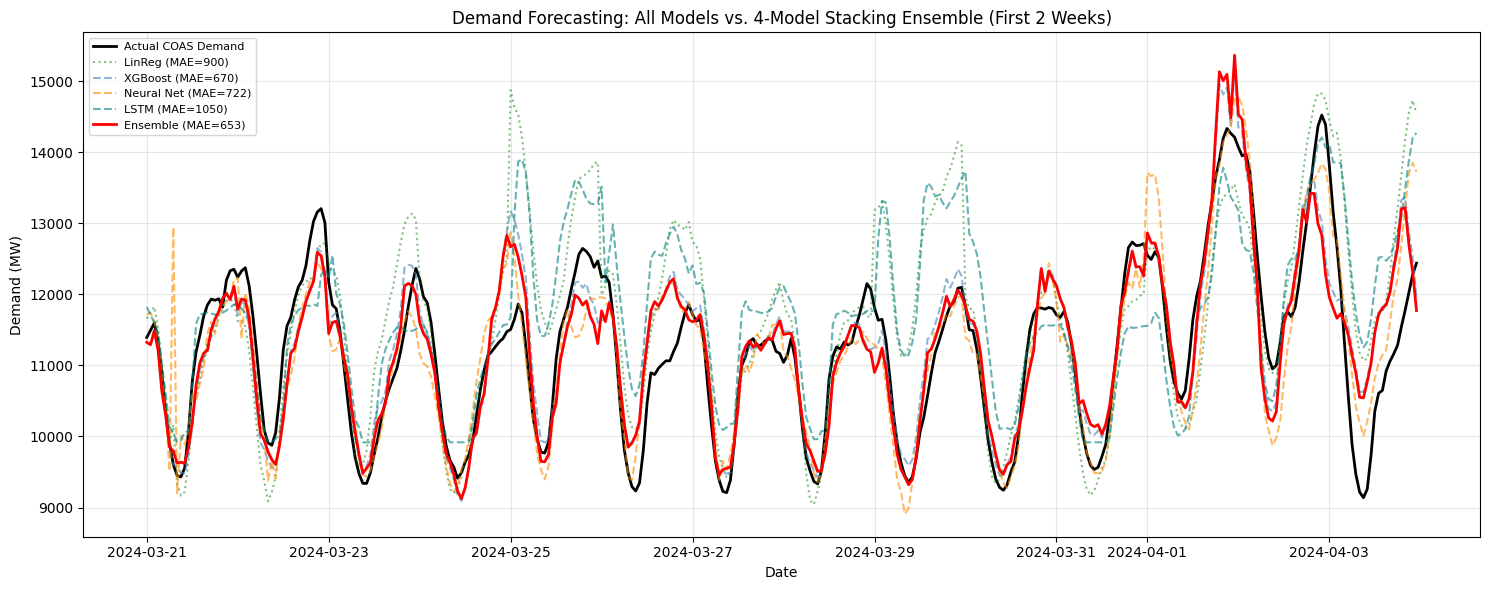

In [33]:

# ── 1. Base-model predictions (test set) ─────────────────────────────────────
lr_pred_test   = lr_model.predict(X_test)
xgb_pred_test  = best_xgb_model.predict(X_test)
nn_pred_test   = nn_model.predict(scaler.transform(X_test))

model.eval()
with torch.no_grad():
    lstm_pred_test_scaled = (
        model(torch.FloatTensor(X_test_seq).to(device))
        .squeeze().cpu().numpy()
    )
lstm_pred_test = target_scaler.inverse_transform(
    lstm_pred_test_scaled.reshape(-1, 1)
).flatten()

# ── 2. Align to LSTM's shifted index ────────────────────────────────────────
lr_pred_test   = lr_pred_test[SEQ_LENGTH:]
xgb_pred_test  = xgb_pred_test[SEQ_LENGTH:]
nn_pred_test   = nn_pred_test[SEQ_LENGTH:]

y_test_aligned      = y_test.iloc[SEQ_LENGTH:]
y_test_aligned_vals = y_test_aligned.values

# ── 3. Base-model predictions (train set, same alignment) ───────────────────
lr_pred_train  = lr_model.predict(X_train)[SEQ_LENGTH:]
xgb_pred_train = best_xgb_model.predict(X_train)[SEQ_LENGTH:]
nn_pred_train  = nn_model.predict(scaler.transform(X_train))[SEQ_LENGTH:]

with torch.no_grad():
    lstm_pred_train_scaled = (
        model(torch.FloatTensor(X_train_seq).to(device))
        .squeeze().cpu().numpy()
    )
lstm_pred_train = target_scaler.inverse_transform(
    lstm_pred_train_scaled.reshape(-1, 1)
).flatten()

y_train_aligned = y_train.iloc[SEQ_LENGTH:]

# ── 4. Stack and train meta-learner ─────────────────────────────────────────
ensemble_X_train = np.column_stack([
    lr_pred_train, xgb_pred_train, nn_pred_train, lstm_pred_train
])
ensemble_X_test = np.column_stack([
    lr_pred_test, xgb_pred_test, nn_pred_test, lstm_pred_test
])

ensemble_model = LinearRegression()
ensemble_model.fit(ensemble_X_train, y_train_aligned)

y_pred_ensemble = ensemble_model.predict(ensemble_X_test)

# ── 5. Evaluate ─────────────────────────────────────────────────────────────
mae_ens  = mean_absolute_error(y_test_aligned_vals, y_pred_ensemble)
rmse_ens = np.sqrt(mean_squared_error(y_test_aligned_vals, y_pred_ensemble))
mape_ens = np.mean(np.abs((y_test_aligned_vals - y_pred_ensemble) / y_test_aligned_vals)) * 100

model_names = ["LinReg", "XGBoost", "NeuralNet", "LSTM"]
print(f"Ensemble (4-model stack) - MAE:  {mae_ens:.2f}")
print(f"Ensemble (4-model stack) - RMSE: {rmse_ens:.2f}")
print(f"Ensemble (4-model stack) - MAPE: {mape_ens:.2f}%")
print(f"\nMeta-learner weights:")
for name, w in zip(model_names, ensemble_model.coef_):
    print(f"  {name:>10s}: {w:.4f}")

# ── 6. Plot first 2 weeks ───────────────────────────────────────────────────
hours_to_plot = 24 * 14
idx = y_test_aligned.index[:hours_to_plot]

plt.figure(figsize=(15, 6))
plt.plot(idx, y_test_aligned_vals[:hours_to_plot],
         label="Actual COAS Demand", color="black", linewidth=2)
plt.plot(idx, lr_pred_test[:hours_to_plot],
         label=f"LinReg (MAE={mean_absolute_error(y_test_aligned_vals, lr_pred_test):.0f})",
         color="green", alpha=0.5, linestyle=":")
plt.plot(idx, xgb_pred_test[:hours_to_plot],
         label=f"XGBoost (MAE={mean_absolute_error(y_test_aligned_vals, xgb_pred_test):.0f})",
         color="steelblue", alpha=0.6, linestyle="--")
plt.plot(idx, nn_pred_test[:hours_to_plot],
         label=f"Neural Net (MAE={mean_absolute_error(y_test_aligned_vals, nn_pred_test):.0f})",
         color="darkorange", alpha=0.6, linestyle="--")
plt.plot(idx, lstm_pred_test[:hours_to_plot],
         label=f"LSTM (MAE={mean_absolute_error(y_test_aligned_vals, lstm_pred_test):.0f})",
         color="teal", alpha=0.6, linestyle="--")
plt.plot(idx, y_pred_ensemble[:hours_to_plot],
         label=f"Ensemble (MAE={mae_ens:.0f})",
         color="red", linewidth=2)
plt.title("Demand Forecasting: All Models vs. 4-Model Stacking Ensemble (First 2 Weeks)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Although ensembling relies heavily on XGBoost, our other models help bring down error as well. We are now ready to compare our model's performance to that of ERCOT's day-ahead predictions.

# 2. Comparing our model's predictions to ERCOT's predictions

ERCOT releases electricity demand forecasts across several horizons. Since one of the features used in our models is energy demand 24h previously, we will compare our predictions to ERCOT's day-ahead predictions.

We start by importing and extracting ERCOT's day-ahead predictions. Notably, they are posted on a different timezone, so we shift the timestamps to align with our previous analysis. Additionally, we only extract the hours in our test set, as we are only comparing for that time period (late March --> late May).

In [37]:
# ── Step 1: Load ERCOT day-ahead forecast and align with our test set ────────

df_ercot_raw = pd.read_csv("ercot_forecast_wide.csv")

# Convert hour-ending to hour-beginning timestamps in Central Time, then to UTC
hours_offset = df_ercot_raw["hourEnding"].astype(str).str.split(":").str[0].astype(int) - 1
local_period = pd.to_datetime(df_ercot_raw["deliveryDate"]) + pd.to_timedelta(hours_offset, unit="h")

# Localize to Central, convert to UTC, then strip tz to match df_final's naive index
df_ercot_raw["period"] = (
    local_period
    .dt.tz_localize("US/Central", ambiguous="NaT", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

df_ercot_raw["Posted"] = pd.to_datetime(df_ercot_raw["postedDatetime"], format="mixed")

# Forecast horizon = delivery time − posting time
df_ercot_raw["Horizon"] = df_ercot_raw["period"] - df_ercot_raw["Posted"]

# Keep only day-ahead forecasts (horizon ≈ 24 h, window 18–30 h)
df_da = df_ercot_raw[
    (df_ercot_raw["Horizon"] >= pd.Timedelta(hours=18))
    & (df_ercot_raw["Horizon"] <= pd.Timedelta(hours=30))
].copy()

# For each delivery hour, pick the forecast closest to exactly 24 h ahead
df_da["Horizon_Error"] = abs(df_da["Horizon"] - pd.Timedelta(hours=24))
df_da = df_da.sort_values("Horizon_Error").drop_duplicates(subset=["period"])

# Final formatting — keep coast column aligned to test-set index
ercot_forecast = (
    df_da[["period", "coast"]]
    .rename(columns={"coast": "ercot_forecast"})
    .set_index("period")
    .sort_index()
)

# Strip tz if needed to match df_final
if df_final.index.tz is None and ercot_forecast.index.tz is not None:
    ercot_forecast.index = ercot_forecast.index.tz_localize(None)

# Restrict to test-set hours
ercot_forecast = ercot_forecast.loc[ercot_forecast.index.isin(y_test_aligned.index)]

print(f"Test set hours:           {len(y_test_aligned)}")
print(f"ERCOT forecasts matched:  {len(ercot_forecast)}")
print(f"Test set range:           {y_test.index.min()} → {y_test.index.max()}")
print(f"ERCOT matched range:      {ercot_forecast.index.min()} → {ercot_forecast.index.max()}")
ercot_forecast.head()

Test set hours:           1728
ERCOT forecasts matched:  1728
Test set range:           2024-03-20 00:00:00 → 2024-05-31 23:00:00
ERCOT matched range:      2024-03-21 00:00:00 → 2024-05-31 23:00:00


,ercot_forecast
period,
2024-03-21 00:00:00,11904.7002
2024-03-21 01:00:00,12021.7998
2024-03-21 02:00:00,11869.0996
2024-03-21 03:00:00,11328.7002
2024-03-21 04:00:00,10746.2998


We now compare our model's predictions to ERCOT's predictions.

Hours compared:   1728
Ensemble MAE:      652.9 MW
ERCOT   MAE:      633.0 MW
Ensemble win rate: 51.4%



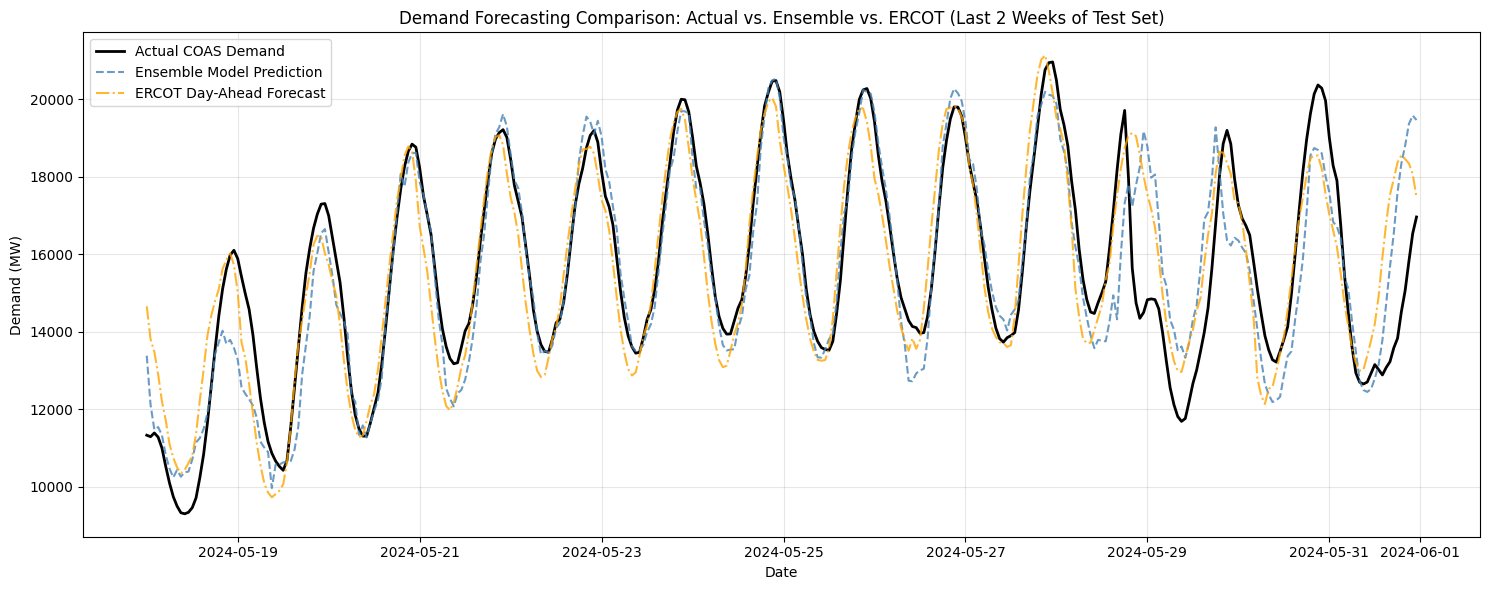

In [40]:
# ── Step 2: Compute error vectors and plot last 2 weeks ─────────────────────

# Build aligned comparison DataFrame (only hours present in both)
error_df = pd.DataFrame({
    "actual": y_test_aligned,
    "ensemble_pred": y_pred_ensemble,
}).join(ercot_forecast, how="inner")

error_df["ensemble_error"]  = error_df["ensemble_pred"]      - error_df["actual"]
error_df["ercot_error"] = error_df["ercot_forecast"] - error_df["actual"]

error_df["abs_ensemble_error"]  = error_df["ensemble_error"].abs()
error_df["abs_ercot_error"] = error_df["ercot_error"].abs()

error_df["ensemble_wins"] = (error_df["abs_ensemble_error"] < error_df["abs_ercot_error"]).astype(int)

ensemble_mae  = error_df["abs_ensemble_error"].mean()
ercot_mae = error_df["abs_ercot_error"].mean()
win_rate  = error_df["ensemble_wins"].mean() * 100

print(f"Hours compared:   {len(error_df)}")
print(f"Ensemble MAE:      {ensemble_mae:.1f} MW")
print(f"ERCOT   MAE:      {ercot_mae:.1f} MW")
print(f"Ensemble win rate: {win_rate:.1f}%\n")

# ── Plot last 2 weeks: Actual vs Ensemble vs ERCOT Day-Ahead ────────────────
hours_to_plot = 24 * 14
plot_slice = error_df.iloc[-hours_to_plot:]

plt.figure(figsize=(15, 6))
plt.plot(plot_slice.index, plot_slice["actual"],
         label="Actual COAS Demand", color="black", linewidth=2)
plt.plot(plot_slice.index, plot_slice["ensemble_pred"],
         label="Ensemble Model Prediction", color="steelblue", alpha=0.8, linestyle="--")
plt.plot(plot_slice.index, plot_slice["ercot_forecast"],
         label="ERCOT Day-Ahead Forecast", color="orange", alpha=0.8, linestyle="-.")

plt.title("Demand Forecasting Comparison: Actual vs. Ensemble vs. ERCOT (Last 2 Weeks of Test Set)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


We achieve comparable performance to ERCOT's model. In terms of MAE, our ensembled model's is slightly higher, but we obtain predictions closer to the actual value more often than ERCOT does. This validates our methodology.

# 3. Analyzing error patterns

In this section, we conduct a K-Means cluster on both our model's and ERCOT's predictions' errors to try and pick up patterns and explain what conditions could make the predictions inaccurate.

Since KMeans clustering relies on a distance metric, like Euclidean distance, we make the day labels and the month labels cyclical as well to capture adjacency between Sunday-Monday and Dec-Jan.

In [44]:

# Key methodology choices (vs. earlier version):
#   1. Cluster ONLY on context/environment features — error columns removed
#      to avoid target leakage (K-Means would otherwise cluster on error
#      magnitude rather than discovering meaningful environmental regimes).
#   2. day_of_week and month are sin/cos encoded (like hour) so Euclidean
#      distance treats Sunday↔Monday and December↔January as adjacent.
#   3. StandardScaler applied ONLY to continuous variables; boolean/one-hot
#      and cyclical sin/cos features are left in their natural [0,1] or
#      [-1,1] range to prevent rare events from becoming huge outliers.

from sklearn.preprocessing import StandardScaler

context_base = X_test.loc[error_df.index].copy()

# Cyclically encode day_of_week (0–6) and month (1–12)
context_base["day_sin"]   = np.sin(2 * np.pi * context_base["day_of_week"] / 7)
context_base["day_cos"]   = np.cos(2 * np.pi * context_base["day_of_week"] / 7)
context_base["month_sin"] = np.sin(2 * np.pi * (context_base["month"] - 1) / 12)
context_base["month_cos"] = np.cos(2 * np.pi * (context_base["month"] - 1) / 12)

# ── Column groups ────────────────────────────────────────────────────────────
continuous_cols = ["tmpf", "dwpf", "relh", "COAS_lag_24h"]
continuous_cols = [c for c in continuous_cols if c in context_base.columns]
cyclical_cols = ["hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos"]
boolean_cols = [
    "is_texans_game",
    "school_category_regular_school_day",
    "school_category_summer_break_weekday",
    "school_category_weekend_school_break",
    "school_category_weekend_school_term",
    "business_category_normal_business_day",
    "business_category_weekend",
]
boolean_cols = [c for c in boolean_cols if c in context_base.columns]

all_cluster_cols = continuous_cols + cyclical_cols + boolean_cols

# Build clean clustering DataFrame (NO error columns)
cluster_df = context_base[all_cluster_cols].dropna()
feature_names = cluster_df.columns.tolist()

# Selective scaling: StandardScaler for continuous features only
scaler = StandardScaler()
cluster_scaled = cluster_df.copy()
cluster_scaled[continuous_cols] = scaler.fit_transform(cluster_df[continuous_cols])
X_cluster = cluster_scaled.values


The code below runs PCA, which essentially identifies the 'dimensions' which best explain our data, reducing the dimensionality (aka number of features) for simpler visualization of our KMeans clustering (see later cells).

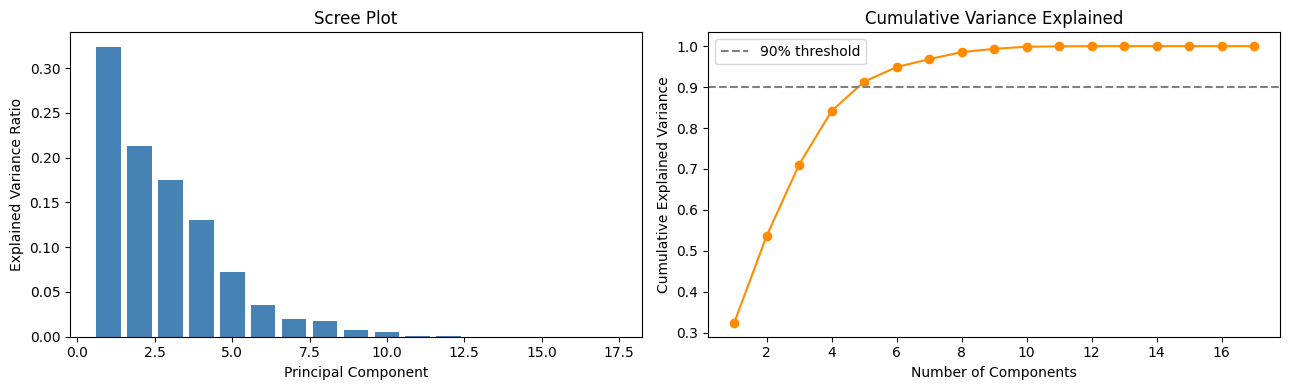

Components needed for ≥90% variance: 5


In [43]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, "o-", color="darkorange")
axes[1].axhline(0.90, ls="--", color="gray", label="90% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()

plt.tight_layout()
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Components needed for ≥90% variance: {n_90}")

More than 50% of our variance (essentially information) is explained by the top 2 'principle components'. This is good - it means we can later plot in these two Principle Components without losing an excessive amount of information.

# THE REST OF THESE CELLS I STILL NEED TO UNDERSTAND AND POTENTIALLY CHANGE - THIS CLUSTERING ANALYSIS IS NOT TRIVIAL / NEED TO FIGURE OUT HOW TO MAKE IT INTERPRETABLE

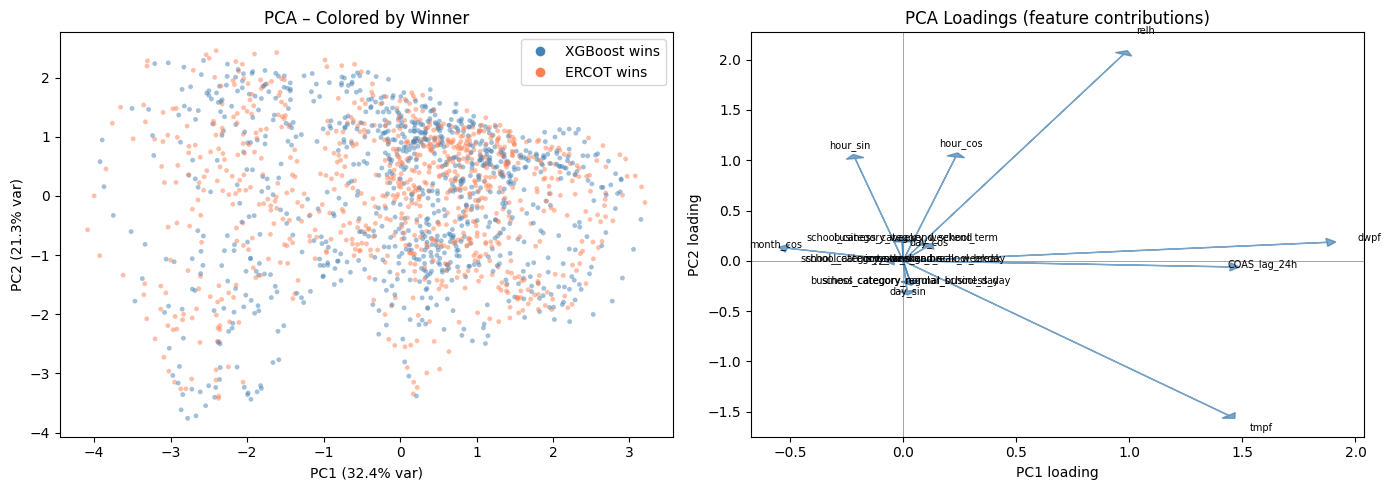

In [46]:
# ── Step 4b: PCA – 2D scatter colored by winner ─────────────────────────────

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_cluster)

# Align ensemble_wins with the rows that survived dropna
ensemble_wins_aligned = error_df.loc[cluster_df.index, "ensemble_wins"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Colored by winner: steelblue = ensemble wins, coral = ERCOT wins
point_colors = np.where(ensemble_wins_aligned == 1, "steelblue", "coral")
scatter = axes[0].scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=point_colors, alpha=0.5, s=12, edgecolors="none"
)
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)")
axes[0].set_title("PCA – Colored by Winner")
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="XGBoost wins"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="coral",     markersize=8, label="ERCOT wins"),
]
axes[0].legend(handles=legend_handles)

# (b) PCA loadings (arrows)
loadings = pca2.components_.T
for i, feat in enumerate(feature_names):
    axes[1].arrow(0, 0, loadings[i, 0] * 3, loadings[i, 1] * 3,
                  head_width=0.08, head_length=0.04, fc="steelblue", ec="steelblue", alpha=0.7)
    axes[1].text(loadings[i, 0] * 3.3, loadings[i, 1] * 3.3, feat, fontsize=7, ha="center")
axes[1].set_xlabel("PC1 loading")
axes[1].set_ylabel("PC2 loading")
axes[1].set_title("PCA Loadings (feature contributions)")
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].axvline(0, color="gray", lw=0.5)

plt.tight_layout()
plt.show()

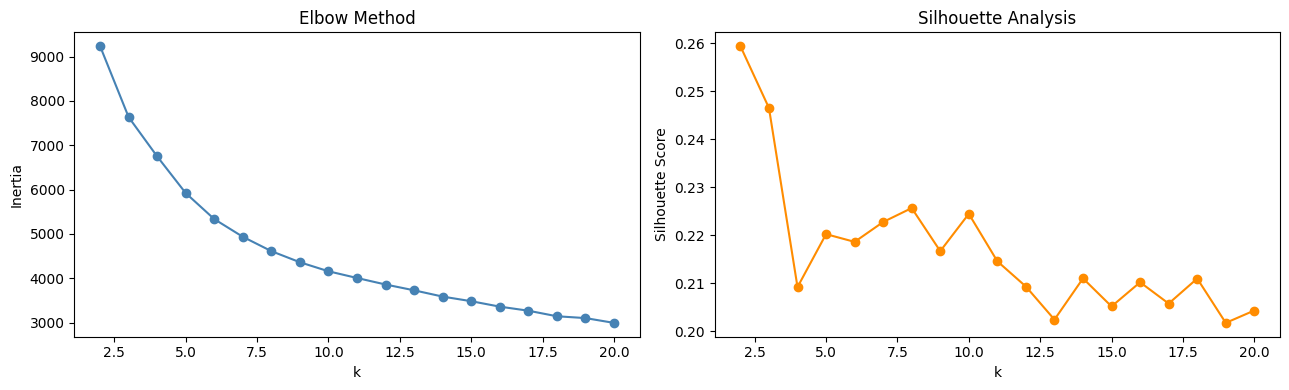

Best k by silhouette score: 2 (score = 0.259)


In [47]:
# ── Step 5a: K-means – elbow and silhouette analysis ─────────────────────────

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 21)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, "o-", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette score: {best_k} (score = {max(silhouettes):.3f})")

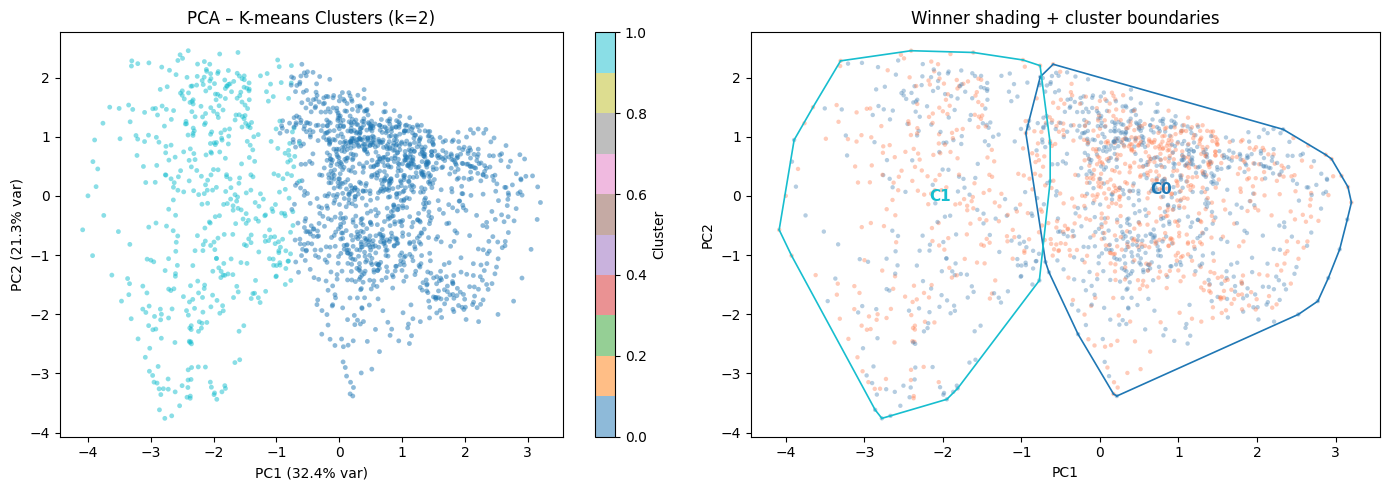

In [50]:
# ── Step 5b: Fit final K-means and plot PCA scatter by cluster ───────────────
best_k = 2

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)

cluster_df["cluster"] = cluster_labels
error_df.loc[cluster_df.index, "cluster"] = cluster_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) PCA colored by cluster
scatter1 = axes[0].scatter(
    X_pca2[:, 0], X_pca2[:, 1],
    c=cluster_labels, cmap="tab10", alpha=0.5, s=12, edgecolors="none"
)
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)")
axes[0].set_title(f"PCA – K-means Clusters (k={best_k})")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# (b) PCA colored by winner, with cluster boundaries via convex hulls
from scipy.spatial import ConvexHull
colors_cluster = plt.cm.tab10(np.linspace(0, 1, best_k))
winner_colors = np.where(ensemble_wins_aligned == 1, "steelblue", "coral")
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1],
                c=winner_colors, alpha=0.4, s=10, edgecolors="none")
for c in range(best_k):
    mask = cluster_labels == c
    if mask.sum() >= 3:
        pts = X_pca2[mask]
        hull = ConvexHull(pts)
        for simplex in hull.simplices:
            axes[1].plot(pts[simplex, 0], pts[simplex, 1], color=colors_cluster[c], lw=1.2)
        axes[1].text(pts[:, 0].mean(), pts[:, 1].mean(), f"C{c}", fontsize=11, fontweight="bold",
                     color=colors_cluster[c], ha="center")
axes[1].set_xlabel(f"PC1")
axes[1].set_ylabel(f"PC2")
axes[1].set_title("Winner shading + cluster boundaries")

plt.tight_layout()
plt.show()

In [52]:
# ── Step 6a: Cluster profiling – summary table ───────────────────────────────

profile_rows = []
analysis_df = error_df.loc[cluster_df.index].copy()
analysis_df["cluster"] = cluster_labels

# Add raw hour for readability (recover from sin/cos)
analysis_df["hour"] = analysis_df.index.hour

for c in sorted(analysis_df["cluster"].unique()):
    sub = analysis_df[analysis_df["cluster"] == c]
    profile_rows.append({
        "cluster": int(c),
        "n_hours": len(sub),
        "ensemble_MAE": sub["abs_ensemble_error"].mean(),
        "ercot_MAE": sub["abs_ercot_error"].mean(),
        "ensemble_win_rate_%": sub["ensemble_wins"].mean() * 100,
        "mean_actual_MW": sub["actual"].mean(),
        "mean_temp_F": X_test.loc[sub.index, "tmpf"].mean() if "tmpf" in X_test.columns else np.nan,
        "peak_hour": sub["hour"].mode().iloc[0] if len(sub) > 0 else np.nan,
        "mean_ensemble_error": sub["ensemble_error"].mean(),
        "mean_ercot_error": sub["ercot_error"].mean(),
    })

profile = pd.DataFrame(profile_rows).round(1)
profile

,cluster,n_hours,ensemble_MAE,ercot_MAE,ensemble_win_rate_%,mean_actual_MW,mean_temp_F,peak_hour,mean_ensemble_error,mean_ercot_error
0,0,1252,737.7,713.9,52.2,13895.5,77.1,23,103.4,56.3
1,1,476,430.0,420.1,49.4,11050.3,65.6,14,32.0,128.3
